In [1]:
# Mount Google Drive (for Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive mounted successfully!")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Not running in Google Colab - skipping drive mount")

# Set project root path
if IN_COLAB:
    PROJECT_ROOT = "/content/drive/MyDrive/face_based_attendance_system"
else:
    from pathlib import Path
    PROJECT_ROOT = str(Path("..").resolve())

print(f"📂 Project root: {PROJECT_ROOT}")

ℹ️  Not running in Google Colab - skipping drive mount
📂 Project root: C:\Users\User\Desktop\AI_ML\face-based_attendance_system


# 04 - Training Optimization

This notebook covers training optimization techniques for efficient face recognition training.

## Topics Covered:
1. Automatic Mixed Precision (AMP)
2. Partial FC for Memory Efficiency
3. Learning Rate Scheduling
4. Gradient Accumulation
5. Distributed Training Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW, SGD
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts
import math
import time
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\AI_ML\face-based_attendance_system\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\AI_ML\face-based_attendance_system\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\User\Desktop\AI_ML\face-based_attendance_system\venv\Lib\site-packages\ipyk

PyTorch version: 2.2.2+cpu
CUDA available: False


## 1. Automatic Mixed Precision (AMP)

AMP uses FP16 for forward/backward passes while maintaining FP32 master weights.

In [3]:
class AMPTrainer:
    """
    Trainer with Automatic Mixed Precision support.
    
    Benefits:
    - 2-3x faster training on modern GPUs
    - ~50% memory reduction
    - Minimal accuracy impact
    """
    def __init__(self, model, optimizer, use_amp=True):
        self.model = model
        self.optimizer = optimizer
        self.use_amp = use_amp and torch.cuda.is_available()
        
        # GradScaler for AMP
        self.scaler = GradScaler(enabled=self.use_amp)
        
        print(f"AMP {'enabled' if self.use_amp else 'disabled'}")
    
    def train_step(self, images, labels, criterion):
        """
        Single training step with AMP.
        """
        self.optimizer.zero_grad()
        
        # Forward pass with autocast
        with autocast(enabled=self.use_amp):
            embeddings = self.model(images)
            loss, logits = criterion(embeddings, labels)
        
        # Backward pass with gradient scaling
        self.scaler.scale(loss).backward()
        
        # Gradient clipping (optional but recommended)
        self.scaler.unscale_(self.optimizer)
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        
        # Optimizer step
        self.scaler.step(self.optimizer)
        self.scaler.update()
        
        return loss.item()


# Demonstrate AMP memory savings
def compare_memory_usage():
    """Compare memory usage with and without AMP."""
    if not torch.cuda.is_available():
        print("CUDA not available, skipping memory comparison")
        return
    
    # Create dummy model and data
    model = nn.Sequential(
        nn.Conv2d(3, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, 512)
    ).cuda()
    
    batch_size = 128
    x = torch.randn(batch_size, 3, 112, 112).cuda()
    
    # Without AMP
    torch.cuda.reset_peak_memory_stats()
    y = model(x)
    loss = y.sum()
    loss.backward()
    mem_fp32 = torch.cuda.max_memory_allocated() / 1e6
    
    # With AMP
    torch.cuda.reset_peak_memory_stats()
    with autocast():
        y = model(x)
        loss = y.sum()
    scaler = GradScaler()
    scaler.scale(loss).backward()
    mem_amp = torch.cuda.max_memory_allocated() / 1e6
    
    print(f"\nMemory Usage Comparison:")
    print(f"  FP32: {mem_fp32:.1f} MB")
    print(f"  AMP:  {mem_amp:.1f} MB")
    print(f"  Savings: {(1 - mem_amp/mem_fp32)*100:.1f}%")

compare_memory_usage()

CUDA not available, skipping memory comparison


## 2. Partial FC for Large-Scale Training

When training with millions of classes, the FC layer becomes a bottleneck.

In [4]:
class PartialFC(nn.Module):
    """
    Partial FC for memory-efficient training with large number of classes.
    
    Instead of computing all class logits, randomly sample a subset.
    
    Memory reduction:
    - Standard FC: O(num_classes × embedding_dim)
    - Partial FC: O(sample_rate × num_classes × embedding_dim)
    """
    def __init__(
        self,
        embedding_dim: int,
        num_classes: int,
        sample_rate: float = 0.1,
        scale: float = 64.0,
        margin: float = 0.5
    ):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.sample_rate = sample_rate
        self.scale = scale
        self.margin = margin
        
        # Full weight matrix
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Precompute margin values
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin
        
        print(f"PartialFC: {num_classes} classes, {sample_rate*100:.0f}% sample rate")
    
    def forward(self, embeddings, labels):
        """
        Forward pass with negative sampling.
        """
        batch_size = embeddings.size(0)
        device = embeddings.device
        
        # Get unique labels in batch (positive classes)
        unique_labels = labels.unique()
        num_positives = len(unique_labels)
        
        # Sample negative classes
        num_negatives = int(self.num_classes * self.sample_rate) - num_positives
        num_negatives = max(0, num_negatives)
        
        # Create mask for all classes
        all_indices = torch.arange(self.num_classes, device=device)
        positive_mask = torch.zeros(self.num_classes, dtype=torch.bool, device=device)
        positive_mask[unique_labels] = True
        
        # Sample from negative classes
        negative_indices = all_indices[~positive_mask]
        if num_negatives > 0 and len(negative_indices) > 0:
            perm = torch.randperm(len(negative_indices), device=device)[:num_negatives]
            sampled_negatives = negative_indices[perm]
            sampled_indices = torch.cat([unique_labels, sampled_negatives])
        else:
            sampled_indices = unique_labels
        
        sampled_indices = sampled_indices.sort()[0]
        
        # Get sampled weights
        sampled_weight = self.weight[sampled_indices]
        sampled_weight_norm = F.normalize(sampled_weight, p=2, dim=1)
        
        # Map labels to sampled indices
        label_mapping = torch.zeros(self.num_classes, dtype=torch.long, device=device)
        label_mapping[sampled_indices] = torch.arange(len(sampled_indices), device=device)
        mapped_labels = label_mapping[labels]
        
        # Compute cosine similarity
        cosine = F.linear(embeddings, sampled_weight_norm)
        
        # Apply ArcFace margin
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot for mapped labels
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, mapped_labels.view(-1, 1), 1)
        
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        
        loss = F.cross_entropy(output, mapped_labels)
        return loss, output


# Example usage
pfc = PartialFC(
    embedding_dim=512,
    num_classes=10000,  # Simulating large class count
    sample_rate=0.1     # Only use 10% of classes per batch
)

# Test forward pass
dummy_embeddings = F.normalize(torch.randn(64, 512), p=2, dim=1)
dummy_labels = torch.randint(0, 1000, (64,))  # Random labels

loss, logits = pfc(dummy_embeddings, dummy_labels)
print(f"\nTest - Loss: {loss.item():.4f}, Logits shape: {logits.shape}")

PartialFC: 10000 classes, 10% sample rate

Test - Loss: 41.0892, Logits shape: torch.Size([64, 1000])


## 3. Learning Rate Scheduling

c:\Users\User\Desktop\AI_ML\face-based_attendance_system\venv\Lib\site-packages\torch\optim\lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


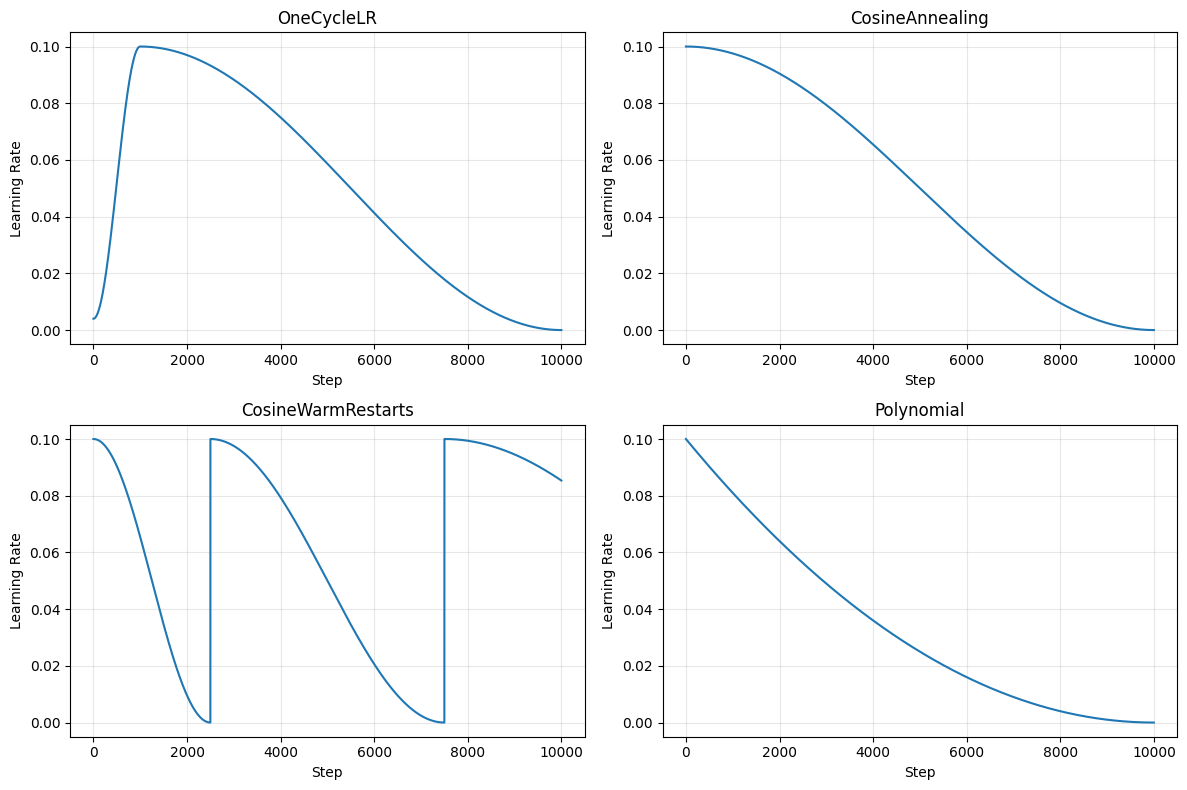

In [5]:
def visualize_lr_schedules(total_steps=10000, base_lr=0.1):
    """Compare different LR schedules."""
    # Create dummy model and optimizer
    model = nn.Linear(10, 10)
    
    schedules = {
        'OneCycleLR': None,
        'CosineAnnealing': None,
        'CosineWarmRestarts': None,
        'Polynomial': None
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for idx, (name, _) in enumerate(schedules.items()):
        optimizer = SGD(model.parameters(), lr=base_lr)
        lrs = []
        
        if name == 'OneCycleLR':
            scheduler = OneCycleLR(
                optimizer, max_lr=base_lr,
                total_steps=total_steps,
                pct_start=0.1,
                anneal_strategy='cos'
            )
        elif name == 'CosineAnnealing':
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=total_steps
            )
        elif name == 'CosineWarmRestarts':
            scheduler = CosineAnnealingWarmRestarts(
                optimizer, T_0=total_steps//4, T_mult=2
            )
        else:  # Polynomial
            scheduler = torch.optim.lr_scheduler.PolynomialLR(
                optimizer, total_iters=total_steps, power=2
            )
        
        for _ in range(total_steps):
            lrs.append(optimizer.param_groups[0]['lr'])
            scheduler.step()
        
        axes[idx].plot(lrs)
        axes[idx].set_title(name)
        axes[idx].set_xlabel('Step')
        axes[idx].set_ylabel('Learning Rate')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

visualize_lr_schedules()

## 4. Gradient Accumulation

In [6]:
class GradientAccumulationTrainer:
    """
    Trainer with gradient accumulation for simulating larger batch sizes.
    
    Effective batch size = batch_size × accumulation_steps × num_gpus
    """
    def __init__(
        self,
        model,
        optimizer,
        criterion,
        accumulation_steps: int = 4,
        use_amp: bool = True
    ):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.accumulation_steps = accumulation_steps
        self.use_amp = use_amp and torch.cuda.is_available()
        
        self.scaler = GradScaler(enabled=self.use_amp)
        self.step_count = 0
    
    def train_step(self, images, labels):
        """
        Training step with gradient accumulation.
        """
        # Forward pass
        with autocast(enabled=self.use_amp):
            embeddings = self.model(images)
            loss, _ = self.criterion(embeddings, labels)
            # Scale loss for accumulation
            loss = loss / self.accumulation_steps
        
        # Backward pass (accumulate gradients)
        self.scaler.scale(loss).backward()
        
        self.step_count += 1
        
        # Only update weights after accumulation_steps
        if self.step_count % self.accumulation_steps == 0:
            # Gradient clipping
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            # Update weights
            self.scaler.step(self.optimizer)
            self.scaler.update()
            self.optimizer.zero_grad()
            
            return loss.item() * self.accumulation_steps, True
        
        return loss.item() * self.accumulation_steps, False


# Example: Simulating 512 batch size with 128 actual batch
actual_batch_size = 128
accumulation_steps = 4
effective_batch_size = actual_batch_size * accumulation_steps

print(f"Actual batch size: {actual_batch_size}")
print(f"Accumulation steps: {accumulation_steps}")
print(f"Effective batch size: {effective_batch_size}")

Actual batch size: 128
Accumulation steps: 4
Effective batch size: 512


## 5. Complete Training Configuration

In [7]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class TrainingConfig:
    """Complete training configuration."""
    # Model
    embedding_dim: int = 512
    num_classes: int = 9131  # VGGFace2 classes
    
    # ArcFace
    arcface_scale: float = 64.0
    arcface_margin: float = 0.5
    
    # Training
    batch_size: int = 128
    accumulation_steps: int = 4  # Effective batch: 512
    num_epochs: int = 20
    num_workers: int = 8
    
    # Optimizer
    optimizer: str = 'sgd'  # 'sgd' or 'adamw'
    base_lr: float = 0.1
    weight_decay: float = 5e-4
    momentum: float = 0.9
    
    # Scheduler
    scheduler: str = 'onecycle'  # 'onecycle', 'cosine', 'polynomial'
    warmup_epochs: float = 0.5
    
    # AMP
    use_amp: bool = True
    
    # Partial FC (for large datasets)
    use_partial_fc: bool = False
    pfc_sample_rate: float = 0.1
    
    # Regularization
    label_smoothing: float = 0.1
    gradient_clip_norm: float = 1.0
    
    # Checkpointing
    save_every_n_epochs: int = 1
    checkpoint_dir: str = 'checkpoints'
    
    # Logging
    log_every_n_steps: int = 100
    use_wandb: bool = True
    wandb_project: str = 'face-recognition'
    
    @property
    def effective_batch_size(self) -> int:
        return self.batch_size * self.accumulation_steps


def create_optimizer(model, config: TrainingConfig):
    """Create optimizer based on config."""
    if config.optimizer.lower() == 'sgd':
        return SGD(
            model.parameters(),
            lr=config.base_lr,
            momentum=config.momentum,
            weight_decay=config.weight_decay,
            nesterov=True
        )
    elif config.optimizer.lower() == 'adamw':
        return AdamW(
            model.parameters(),
            lr=config.base_lr,
            weight_decay=config.weight_decay,
            betas=(0.9, 0.999)
        )
    else:
        raise ValueError(f"Unknown optimizer: {config.optimizer}")


def create_scheduler(optimizer, config: TrainingConfig, total_steps: int):
    """Create LR scheduler based on config."""
    warmup_steps = int(total_steps * config.warmup_epochs / config.num_epochs)
    
    if config.scheduler.lower() == 'onecycle':
        return OneCycleLR(
            optimizer,
            max_lr=config.base_lr,
            total_steps=total_steps,
            pct_start=config.warmup_epochs / config.num_epochs,
            anneal_strategy='cos',
            div_factor=25,
            final_div_factor=1000
        )
    elif config.scheduler.lower() == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=total_steps
        )
    elif config.scheduler.lower() == 'polynomial':
        return torch.optim.lr_scheduler.PolynomialLR(
            optimizer, total_iters=total_steps, power=2
        )
    else:
        raise ValueError(f"Unknown scheduler: {config.scheduler}")


# Print example config
config = TrainingConfig()
print("Training Configuration:")
print(f"  Batch size: {config.batch_size}")
print(f"  Effective batch size: {config.effective_batch_size}")
print(f"  Base LR: {config.base_lr}")
print(f"  AMP: {config.use_amp}")
print(f"  Epochs: {config.num_epochs}")

Training Configuration:
  Batch size: 128
  Effective batch size: 512
  Base LR: 0.1
  AMP: True
  Epochs: 20


## 6. Summary

### Key Optimization Techniques:

1. **AMP (Automatic Mixed Precision)**
   - 2-3x faster training
   - ~50% memory reduction
   - Use GradScaler for stability

2. **Partial FC**
   - Essential for >10K classes
   - 10% sample rate works well
   - Minimal accuracy impact

3. **Learning Rate Scheduling**
   - OneCycleLR for fast convergence
   - Warmup prevents early divergence

4. **Gradient Accumulation**
   - Simulate larger batches
   - Essential for limited GPU memory

### Next Steps:
- Proceed to full training notebook
- Run training on VGGFace2